In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo

### DA testing with GLM (Sex model)

In [2]:
mdata_nk_sex = mu.read("/scratch/user/s4575250/BIOX7014_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_milo_nhoods_built.h5mu")

In [3]:
mdata_nk_sex

MuData object with n_obs × n_vars = 187301 × 48457
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'index_cell', 'kth_di

In [4]:
milo.da_nhoods(
    mdata_nk_sex,
    design="~ Batch + Age_years + Sex",
    model_contrasts="SexMale - SexFemale",
    solver="pydeseq2"                  
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 3.51 seconds.

Fitting MAP dispersions...
... done in 2.17 seconds.

Fitting dispersions...
... done in 2.24 seconds.

Fitting MAP dispersions...
... done in 2.17 seconds.

Fitting dispersions...
... done in 2.20 seconds.

Fitting MAP dispersions...
... done in 2.38 seconds.

Fitting dispersions...
... done in 2.22 seconds.

Fitting MAP dispersions...
... done in 2.40 seconds.

Fitting dispersions...
... done in 2.19 seconds.

Fitting MAP dispersions...
... done in 2.36 seconds.

Fitting dispersions...
... done in 2.20 seconds.

Fitting MAP dispersions...
... done in 2.38 seconds.

Fitting dispersions...
... done in 2.17 seconds.

Fitting MAP dispersions...
... done in 2.39 seconds.

Fitting dispersions.

Log2 fold change & Wald test p-value: Sex Male vs Female
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      2.405033        0.147559  0.449354  0.328380  0.742624  0.999086
1      1.031034        0.340997  0.561562  0.607230  0.543698  0.999086
2      2.242339        0.289997  0.362284  0.800469  0.423439  0.999086
3      4.291640        0.467861  0.484653  0.965354  0.334367  0.999086
4      2.282669       -0.311585  0.295224 -1.055419  0.291234  0.999086
...         ...             ...       ...       ...       ...       ...
9846   0.887164       -0.671635  0.421118 -1.594886  0.110738  0.989700
9847  11.808871        0.218158  0.815411  0.267543  0.789051  0.999086
9848   1.608007       -0.471854  0.558999 -0.844105  0.398611  0.999086
9849   1.049268       -0.250222  0.400054 -0.625471  0.531662  0.999086
9850   2.368651        0.188808  0.282968  0.667242  0.504617  0.999086

[9851 rows x 6 columns]


... done in 1.49 seconds.



In [5]:
mdata_nk_sex["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [6]:
mdata_nk_sex["milo"].uns

{'sample_col': 'pica_id'}

In [7]:
# Check what model_contrasts was stored
print(mdata_nk_sex["milo"].uns.get("model_contrasts"))
print(mdata_nk_sex["milo"].uns.get("contrast"))

None
None


In [8]:
# Check what contrast was actually used
print("Model uns:", mdata_nk_sex["milo"].uns)

# Check the logFC values
print("\nlogFC head:")
print(mdata_nk_sex["milo"].var["logFC"].head(10))

# Check range makes sense
print("\nlogFC range:")
print(mdata_nk_sex["milo"].var["logFC"].describe())

# Check p-values are not all 1
print("\nPValue head:")
print(mdata_nk_sex["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0    0.147559
1    0.340997
2    0.289997
3    0.467861
4   -0.311585
5    0.030743
6   -0.035419
7    0.104715
8    0.069535
9   -0.295824
Name: logFC, dtype: float64

logFC range:
count    9851.000000
mean       -0.044328
std         0.405556
min        -1.633897
25%        -0.310494
50%        -0.049444
75%         0.211455
max         1.504643
Name: logFC, dtype: float64

PValue head:
0    0.742624
1    0.543698
2    0.423439
3    0.334367
4    0.291234
5    0.940192
6    0.924737
7    0.789833
8    0.911754
9    0.525347
Name: PValue, dtype: float64


In [9]:
mdata_nk_sex["milo"].obs["pica_id"] = mdata_nk_sex["milo"].obs.index

In [10]:
mdata_nk_sex["milo"].obs["Age_group"] = pd.cut(
    mdata_nk_sex["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_nk_sex["milo"].obs["Age_group"] = pd.Categorical(
    mdata_nk_sex["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [11]:
mdata_nk_sex["milo"].obs

,Sex,Age_years,Batch,pica_id,Age_group
PICA0001,Male,2.09,Batch01,PICA0001,0-3
PICA0002,Male,15.09,Batch01,PICA0002,15-18
PICA0003,Male,0.83,Batch01,PICA0003,0-3
PICA0004,Male,1.46,Batch01,PICA0004,0-3
PICA0005,Male,9.30,Batch01,PICA0005,7-10
...,...,...,...,...,...
PICA0164,Male,2.15,Batch07,PICA0164,0-3
PICA0166,Male,0.62,Batch07,PICA0166,0-3
PICA0168,Male,16.20,Batch07,PICA0168,15-18
PICA0169,Male,2.72,Batch07,PICA0169,0-3


In [12]:
mdata_nk_sex["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.457598,2.405033,0.147559,0.742624,0.999086,0.999004
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.667299,1.031034,0.340997,0.543698,0.999086,0.999004
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.363439,2.242339,0.289997,0.423439,0.999086,0.999004
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.538970,4.291640,0.467861,0.334367,0.999086,0.994483
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.390574,2.282669,-0.311585,0.291234,0.999086,0.994483
...,...,...,...,...,...,...,...
9846,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.708672,0.887164,-0.671635,0.110738,0.989700,0.983342
9847,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,4.008997,11.808871,0.218158,0.789051,0.999086,0.999004
9848,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.595360,1.608007,-0.471854,0.398611,0.999086,0.999004
9849,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,4.445430,1.049268,-0.250222,0.531662,0.999086,0.999004


In [13]:
mdata_nk_sex.write_h5mu("/scratch/user/s4575250/BIOX7014_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_sex_combined_annot_with_age_nhood.h5mu")

In [14]:
mdata_nk_sex=mu.read_h5mu("/scratch/user/s4575250/BIOX7014_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_sex_combined_annot_with_age_nhood.h5mu")

In [15]:
mdata_nk_sex["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_milo/nk_milo_sex_results.csv")

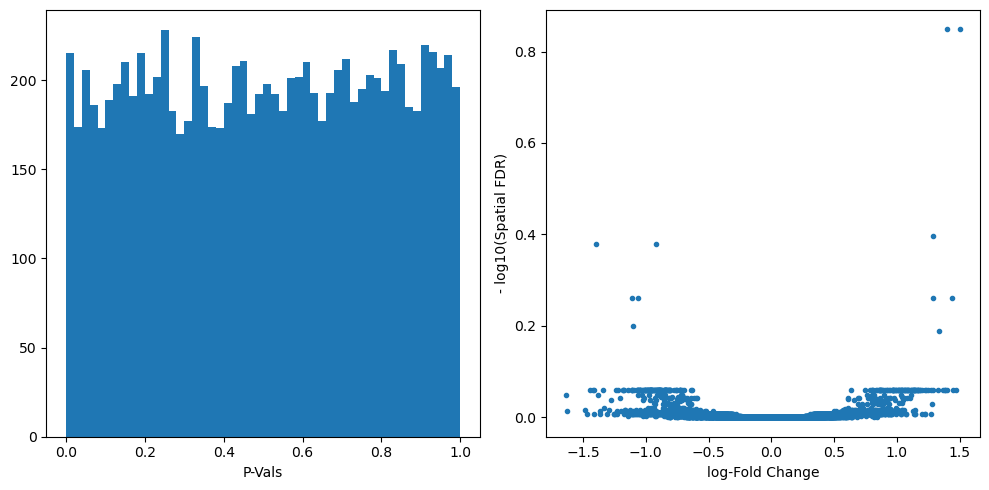

In [16]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_nk_sex["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_nk_sex["milo"].var.logFC, -np.log10(mdata_nk_sex["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

### Visualize embedding

In [17]:
milo.build_nhood_graph(mdata_nk_sex)

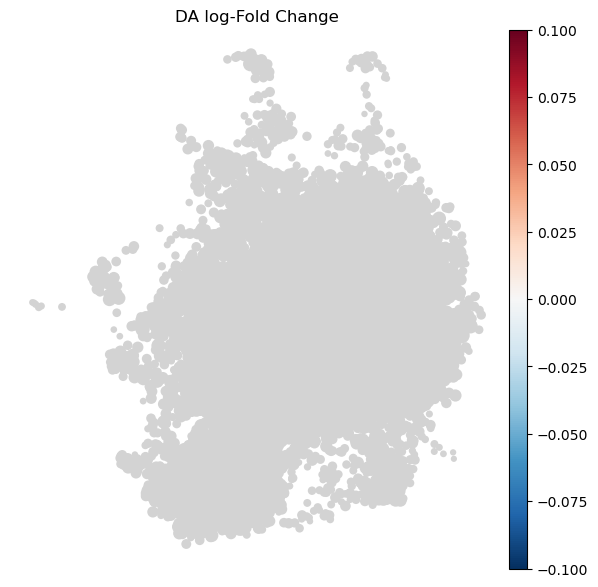

In [18]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_nk_sex,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot, change if needed
)

### Visualize by cell type

In [19]:
milo.annotate_nhoods(mdata_nk_sex, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

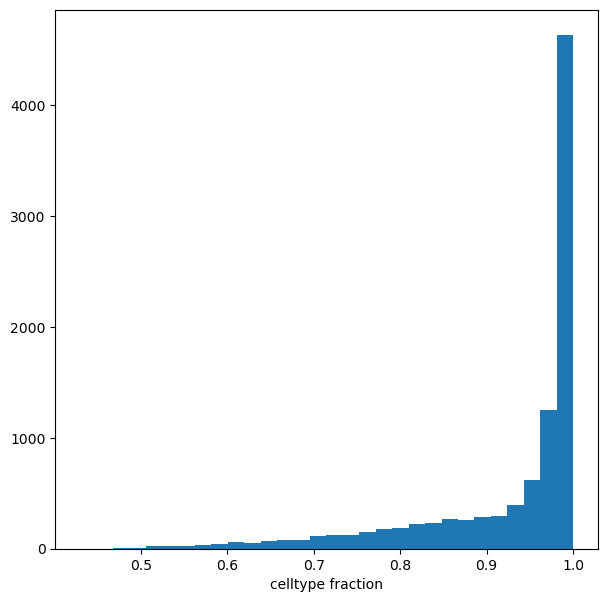

In [20]:
plt.hist(mdata_nk_sex["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [21]:
mdata_nk_sex["milo"].var["nhood_annotation"] = mdata_nk_sex["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_nk_sex["milo"].var.loc[mdata_nk_sex["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1053: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.stripplot(


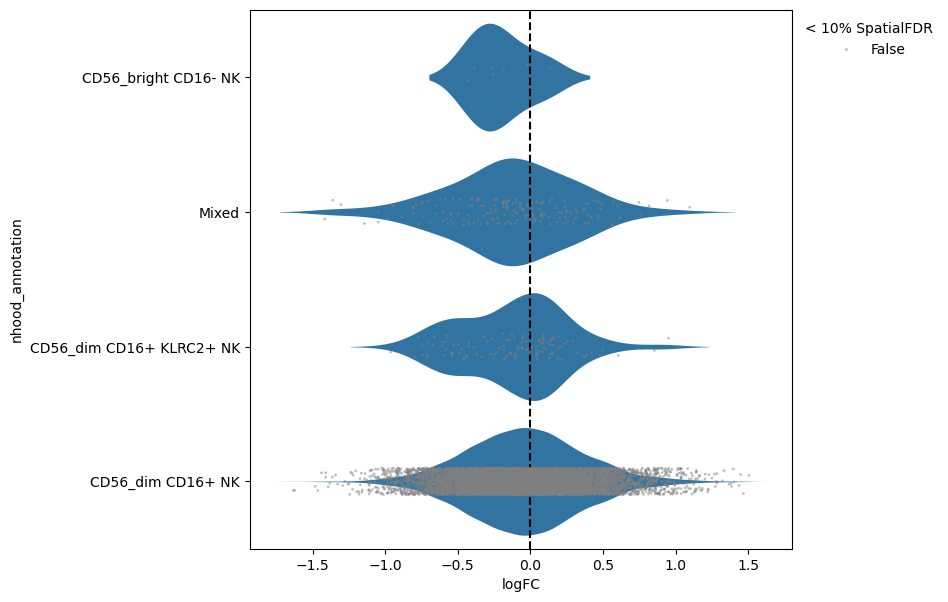

In [22]:
milo.plot_da_beeswarm(mdata_nk_sex, alpha=0.1)

In [23]:
sig_nhoods_nk_sex = mdata_nk_sex["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_nk_sex.sort_values("logFC", ascending=True).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac


In [24]:
sig_nhoods_nk_sex.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_milo/nk_sig_nhood_sex_milo_results.csv")

<Axes: >

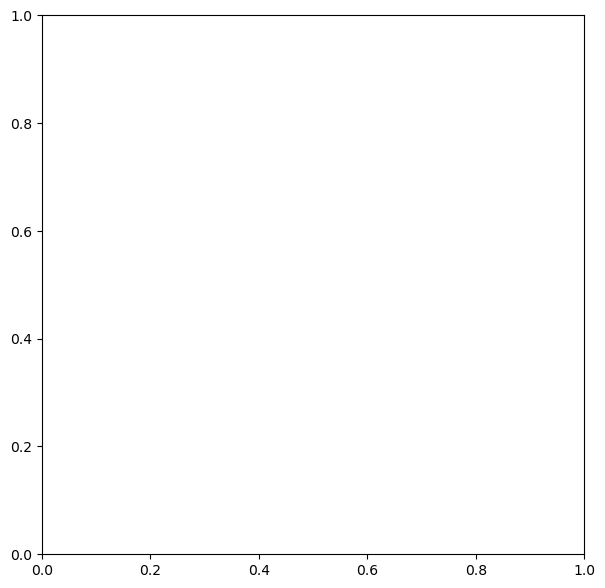

In [25]:
sns.scatterplot(
    data=sig_nhoods_nk_sex,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_nk_sex["SpatialFDR"] < 0.05)
)

In [26]:
pl_nhoods_nk_sex = (
    mdata_nk_sex["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

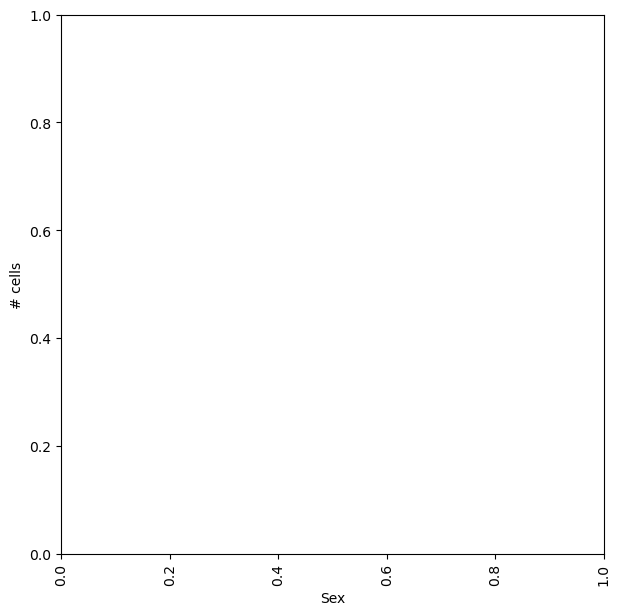

In [27]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk_sex, test_var="Sex", subset_nhoods=pl_nhoods_nk_sex, log_counts=False)

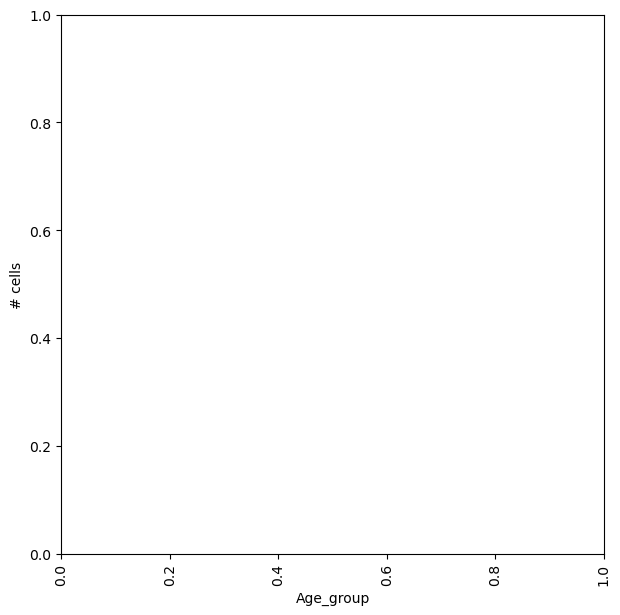

In [28]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk_sex, test_var="Age_group", subset_nhoods=pl_nhoods_nk_sex, log_counts=False)

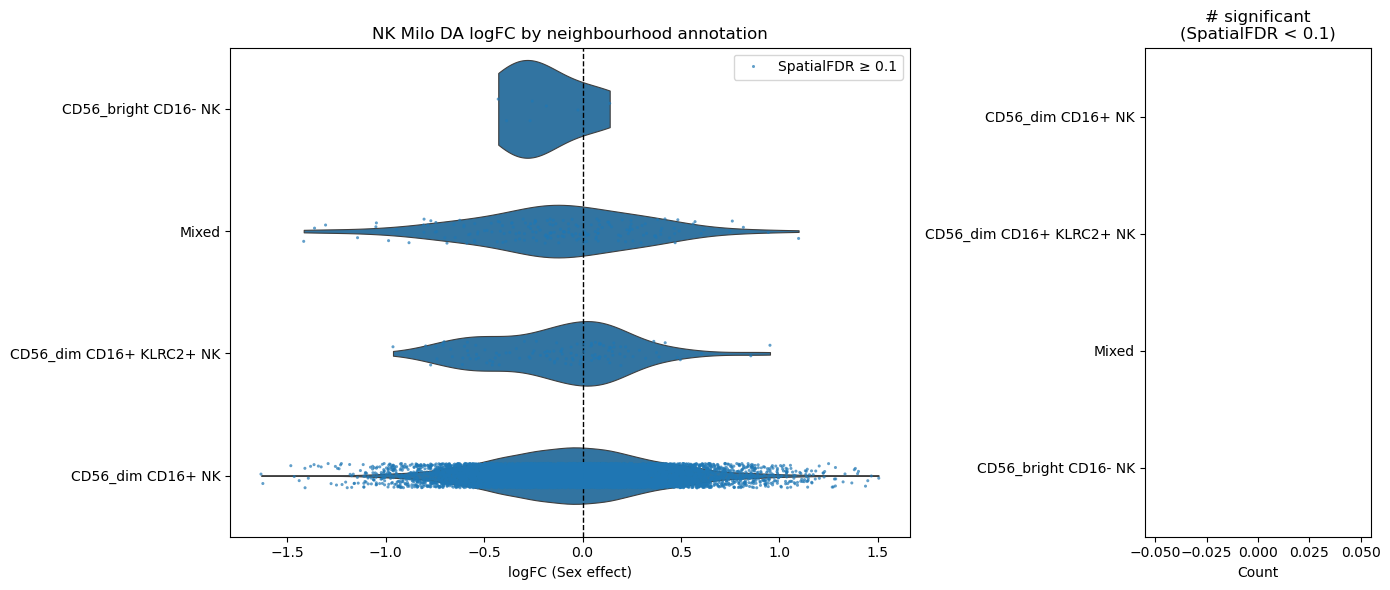

In [29]:
# full nhood results
df_nk_sex = mdata_nk_sex["milo"].var.copy()

# make sure the key columns exist
# df should already have: logFC, SpatialFDR, nhood_annotation
df_nk_sex["sig"] = df_nk_sex["SpatialFDR"] < 0.1

# (optional) order annotations by median logFC (most depleted on top)
order = (
    df_nk_sex.groupby("nhood_annotation")["logFC"]
      .median()
      .sort_values()  # depleted (more negative) first
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_nk_sex, y="nhood_annotation", x="logFC",
    order=order, inner=None, cut=0, linewidth=0.8, ax=axes[0]
)
sns.stripplot(
    data=df_nk_sex, y="nhood_annotation", x="logFC",
    order=order, hue="sig", dodge=False, size=2.2,
    alpha=0.7, ax=axes[0]
)
axes[0].axvline(0, ls="--", c="k", lw=1)
axes[0].set_title("NK Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Sex effect)")
axes[0].set_ylabel("")

# clean up legend (keep only one)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"], title="", loc="upper right")

# ---- Panel B: counts of significant nhoods per annotation ----
sig_counts = (
    df_nk_sex[df_nk_sex["sig"]]
    .groupby("nhood_annotation")
    .size()
    .reindex(order, fill_value=0)
)

axes[1].barh(sig_counts.index, sig_counts.values)
axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()